In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay

# 1. Load the Churn Modelling datase

In [5]:
df=pd.read_csv(r'C:\Users\EB\Downloads\Loandata.csv')

In [7]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# 2 DATA CLEANING

In [6]:
#count the number of missing values
df.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [8]:
## Fill missing  values
cat_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History', 'LoanAmount','Credit_History','Loan_Amount_Term']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [10]:
#Checking if the missing value fill
df.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [30]:
df.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,120.0,360.0,1.0,1,True,False,False,False,False,False,False,False,True
1,4583,1508.0,128.0,360.0,1.0,0,True,True,True,False,False,False,False,False,False
2,3000,0.0,66.0,360.0,1.0,1,True,True,False,False,False,False,True,False,True
3,2583,2358.0,120.0,360.0,1.0,1,True,True,False,False,False,True,False,False,True
4,6000,0.0,141.0,360.0,1.0,1,True,False,False,False,False,False,False,False,True


# 3 Visualize Key Features

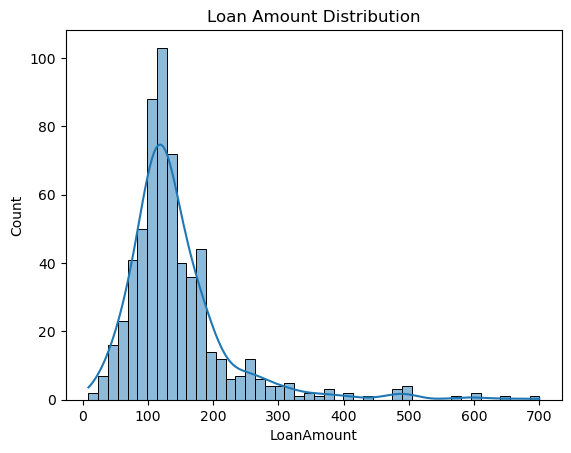

In [11]:
# Plotting Loan Amount Distribution
sns.histplot(df['LoanAmount'], kde=True)
plt.title('Loan Amount Distribution')
plt.show()

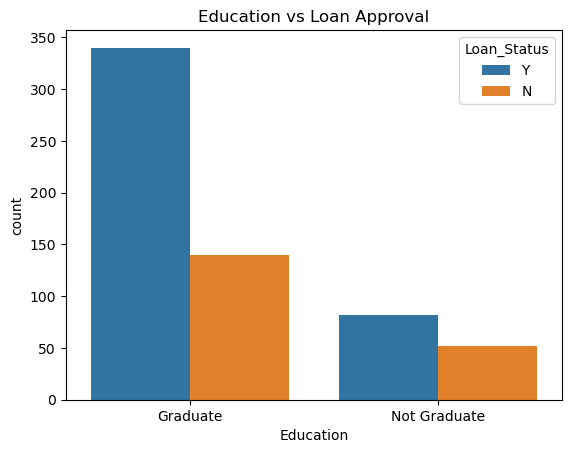

In [12]:
# Education vs Loan Status
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.title('Education vs Loan Approval')
plt.show()

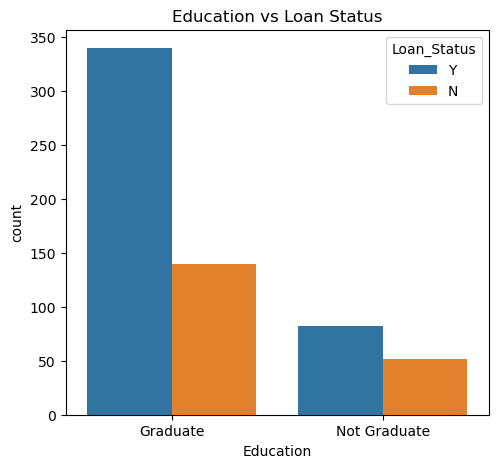

In [14]:
# Education vs Loan Status
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.title('Education vs Loan Status')
plt.show()

# 4.Preprocessing

In [15]:
# Convert categorical to numerical
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})
df = pd.get_dummies(df.drop('Loan_ID', axis=1), drop_first=True)

In [23]:
# Split features and target
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=5000,solver='lbfgs')
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

In [22]:
Confusion matrix
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")

Accuracy Score: 0.79


# 5. Confusion matrix

In [29]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[18 25]
 [ 1 79]]


# 6.classification_repor

In [35]:
print(classification_report(y_test, y_pred, target_names=['Default (0)', 'Approved (1)']))

              precision    recall  f1-score   support

 Default (0)       0.95      0.42      0.58        43
Approved (1)       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123

